In [1]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)
from utils.uhi.georef import *

In [2]:
# Load a transect folder
# transect = load_transect(r"E:\mjosa_new\use_gref4hsi\221\Input\H5")
transect = load_transect(r"E:\mjosa\29\uhi_rad")
transect.list_files()

⚠️  rad_uhi_20241029_104221_1.h5: radiance found but no georef dataset – loaded anyway
⚠️  rad_uhi_20241029_104221_2.h5: radiance found but no georef dataset – loaded anyway
⚠️  rad_uhi_20241029_104221_3.h5: radiance found but no georef dataset – loaded anyway
⚠️  rad_uhi_20241029_104221_4.h5: radiance found but no georef dataset – loaded anyway
⚠️  rad_uhi_20241029_104221_5.h5: radiance found but no georef dataset – loaded anyway
⚠️  rad_uhi_20241029_111520_from1_1.h5: radiance found but no georef dataset – loaded anyway
⚠️  rad_uhi_20241029_111520_from3_1.h5: radiance found but no georef dataset – loaded anyway
⚠️  rad_uhi_20241029_111520_from3_2.h5: radiance found but no georef dataset – loaded anyway
⚠️  rad_uhi_20241029_111520_from3_3.h5: radiance found but no georef dataset – loaded anyway
⚠️  rad_uhi_20241029_115057_1.h5: radiance found but no georef dataset – loaded anyway
⚠️  rad_uhi_20241029_115057_2.h5: radiance found but no georef dataset – loaded anyway
⚠️  rad_uhi_2024102

In [3]:
cube = transect.select_files(
    [
        # "rad_uhi_20241029_121639_1",
        # "rad_uhi_20241029_121639_2",
        # "rad_uhi_20241029_121639_3",
        "rad_uhi_20241029_121639_4",
        # "rad_uhi_20241029_121639_5",
    ]
)
cube.describe()

# cube.apply_illumination_correction_v2(force_recompute=True)

⚠️  Files have no georef data - skipping spatial grid building
✅ Spectral analysis functions available (plot_spectrum, illumination correction, etc.)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_121639_4...
✅ Loaded full cube: (2487, 968, 210) (T × S × B)

=== Combined_uhi_rad ===
Datacube shape: 2487 tracks × 968 slits × 210 bands
Wavelength range: 380.9 - 748.6 nm

⚠️  No georef data available
✅ Spectral analysis functions available: plot_spectrum, illumination correction, etc.
✅ Loaded full cube: (2487, 968, 210) (T × S × B)

=== Combined_uhi_rad ===
Datacube shape: 2487 tracks × 968 slits × 210 bands
Wavelength range: 380.9 - 748.6 nm

⚠️  No georef data available
✅ Spectral analysis functions available: plot_spectrum, illumination correction, etc.


v3 is the best verison, use strategy = memeory. havent tested the others, but this one is fastest but uses most memeory

In [4]:
# Test all strategies:
cube.apply_illumination_correction_v3(
    window_size=500, strategy="memory", force_recompute=False
)

🔄 Using V3 algorithm (rolling window only, strategy=memory)
✅ Illumination correction already exists (window=500, strength=1.0)
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_121639_4: window=500, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_121639_4: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[1.67001677e+00, 1.40526867e+00, 0.00000000e+00, ...,
         0.00000000e+00, 5.96795654e+00, 1.00993896e+02],
        [2.35992742e+00, 1.98882294e+00, 0.00000000e+00, ...,
         3.55457420e+01, 3.48959029e-01, 1.78534198e+00],
        [1.67510498e+00, 4.11764473e-01, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 2.43084431e+00],
        ...,
        [1.77333355e+00, 1.58910096e+00, 0.00000000e+00, ...,
         1.85675564e+01, 0.00000000e+00, 1.46893322e+00],
        [1.60449123e+00, 1.22497225e+00, 1.31028366e+00, ...,
         0.00000000e+00, 5.08596718e-01, 6.87189102e+00],
        [2.71673703e+00, 1.14064682e+00, 0.00000000e+00, ...,
         1.53619576e+00, 5.41964022e-04, 1.80564010e+00]],

       [[9.16247904e-01, 1.40526867e+00, 2.14943194e+00, ...,
         5.72476024e-03, 1.00000000e+00, 1.35991760e+02],
        [0.00000000e+00, 1.65952241e+00, 0.00000000e+00, ...,
         1.91819687e+01, 2.83854902e-01, 1.06858835e+01],
        [0.00000000e+00, 

In [5]:
# cube.apply_illumination_correction_v3(window_size=500, strategy="twopass")

In [6]:
# cube.apply_illumination_correction_v3(window_size=500, strategy="streaming")

✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📊 Extent: x=[0, 2487], y=[0, 968]
📐 Image shape after transformations: (968, 2487, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers


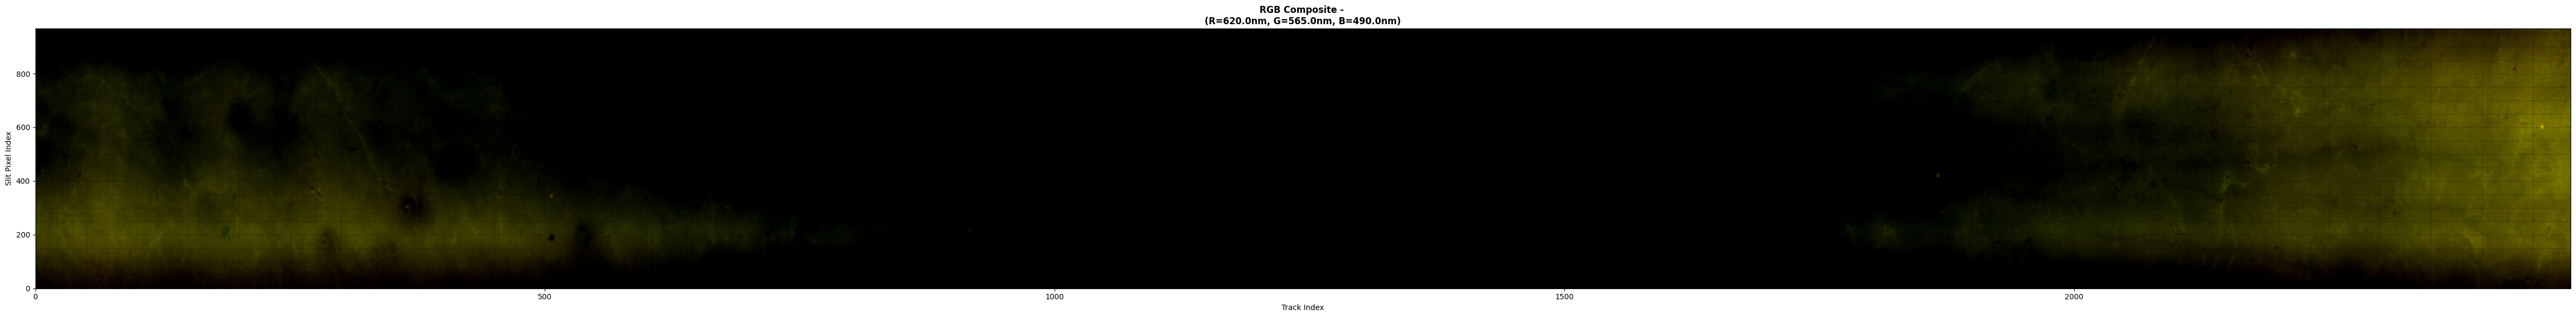

✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📊 Extent: x=[0, 2487], y=[0, 968]
📐 Image shape after transformations: (968, 2487, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers


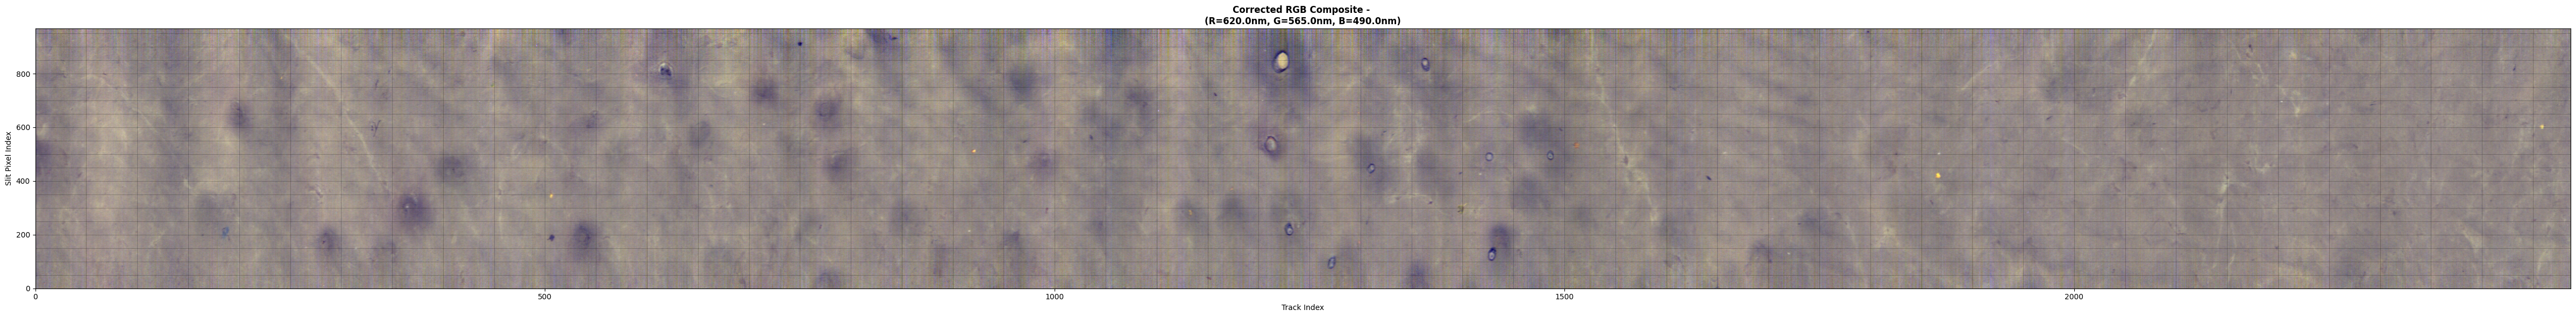

In [7]:
cube.plot_rgb(
    use_corrected=False,
)
cube.plot_rgb(
    use_corrected=True,
)

In [10]:
%matplotlib qt
cube.plot_rgb(
    use_corrected=True,
    show_ticks=False,
)

✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📊 Extent: x=[0, 2487], y=[0, 968]
📐 Image shape after transformations: (968, 2487, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers
📊 Extent: x=[0, 2487], y=[0, 968]
📐 Image shape after transformations: (968, 2487, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers


In [9]:
# Reload module to get updated plot_rgb (removes file boundaries when show_ticks=False)
import importlib
from utils.uhi import georef

importlib.reload(georef)
print(
    "✓ Module reloaded - file boundaries/crosshairs now disabled with show_ticks=False"
)

✓ Module reloaded - file boundaries/crosshairs now disabled with show_ticks=False
